# Segmented TSP - Ant Colony Optimizations


In [ ]:
%pip install requests folium numpy matplotlib pandas

In [ ]:
import requests
import numpy as np
import folium
import random
import math
import matplotlib.pyplot as plt
import pandas as pd
import time
import os
from pathlib import Path

random.seed(42)
np.random.seed(42)

OSRM_BASE = "https://router.project-osrm.org"
PROFILE = "driving"
RETURN_TO_DEPOT = True


In [ ]:
NUM_VEHICLES = 5
RETURN_TO_DEPOT = True
ASSIGNMENT_STRATEGY = 'geographic'
WATER_CSV_PATH = "water.csv"
WATER_ASSIGNMENT_STRATEGY = 'nearest'
TANK_CAPACITY = 8000

print(f"Multi-vehicle mode: {NUM_VEHICLES} vehicles, strategy={ASSIGNMENT_STRATEGY}")
print(f"Water source file : {WATER_CSV_PATH}")
print(f"Tank capacity     : {TANK_CAPACITY} liters")


Multi-vehicle mode: 5 vehicles, strategy=geographic
Water source file : water.csv
Tank capacity     : 8000 liters


## 1. Define Depot and Load Data from CSV

Each park is a **segment** with `start_lat`, `start_lon`, `end_lat`, `end_lon`, and a `demand` column (liters of water needed). Water sources are loaded from a separate CSV.


In [ ]:
DEPOT = (-7.278358153631059, 112.76325243881848)
CSV_PATH = "parks-demand.csv"

REQUIRED_COLUMNS = ["start_lat", "start_lon", "end_lat", "end_lon"]
df_segments = pd.read_csv(CSV_PATH)

for col in ["length (m)", "width (m)", "area (m2)", "demand"]:
    if col in df_segments.columns:
        df_segments[col] = (
            df_segments[col].astype(str)
            .str.replace(",", ".", regex=False)
            .astype(float)
        )

missing_cols = [c for c in REQUIRED_COLUMNS if c not in df_segments.columns]
if missing_cols:
    raise ValueError(f"CSV is missing required columns: {missing_cols}")

def build_segment_name(row, idx):
    if "id" in row.index and pd.notna(row["id"]):
        return str(row["id"])
    return f"Segment {idx + 1}"

PLANTS = []
for idx, row in df_segments.iterrows():
    demand_val = float(row["demand"]) if "demand" in row.index and pd.notna(row["demand"]) else 0.0
    PLANTS.append({
        "name":      build_segment_name(row, idx),
        "start_lat": float(row["start_lat"]),
        "start_lon": float(row["start_lon"]),
        "end_lat":   float(row["end_lat"]),
        "end_lon":   float(row["end_lon"]),
        "demand":    demand_val,
    })

print(f"Loaded {len(PLANTS)} park segments from {CSV_PATH}")
display(df_segments.head(10))

WATER_REQUIRED_COLS = ["water_id", "lat", "lon"]
df_water = pd.read_csv(WATER_CSV_PATH)
missing_water_cols = [c for c in WATER_REQUIRED_COLS if c not in df_water.columns]
if missing_water_cols:
    raise ValueError(f"Water source CSV is missing columns: {missing_water_cols}")

WATER_SOURCES = []
for _, row in df_water.iterrows():
    WATER_SOURCES.append({
        "water_id": str(row["water_id"]).strip(),
        "lat":      float(row["lat"]),
        "lon":      float(str(row["lon"]).strip()),
    })

print(f"Loaded {len(WATER_SOURCES)} water source(s) from {WATER_CSV_PATH}")
display(df_water)

total_demand = sum(p["demand"] for p in PLANTS)
print(f"\nTotal demand across all segments: {total_demand:,.0f} liters")
print(f"Avg demand per segment: {total_demand / len(PLANTS):,.0f} liters")
print(f"Tank capacity: {TANK_CAPACITY} liters")
print(f"Min refills needed (fleet): {math.ceil(total_demand / TANK_CAPACITY)}")


Loaded 34 park segments from parks-demand.csv


,id,start_lat,start_lon,end_lat,end_lon,length (m),width (m),area (m2),demand
0,Jalan Kenjeran,-7.252887,112.795292,-7.249851,112.784502,1250.0,4.0,5000.0,3750.0
1,Jalan Raya Mulyosari,-7.258301,112.795617,-7.273659,112.797714,575.0,2.0,1150.0,862.5
2,Jalan Raya Kertajaya Indah,-7.279408,112.789619,-7.280560,112.781162,950.0,9.0,8550.0,6412.5
3,Jalan Raya Kertajaya Indah,-7.280611,112.780693,-7.279390,112.762482,2000.0,5.0,10000.0,7500.0
4,Jalan Kertajaya,-7.279360,112.762112,-7.278325,112.756143,660.0,9.0,5940.0,4455.0
5,Jalan Kertajaya,-7.278264,112.755534,-7.277394,112.750760,525.0,9.0,4725.0,3543.8
6,Jalan Doktor Insinyur Haji Soekarno,-7.250032,112.784244,-7.254943,112.782404,578.0,7.0,4046.0,3034.5
7,Jalan Kalijudan,-7.255050,112.782372,-7.263295,112.783069,935.0,7.0,6545.0,4908.8
8,Jalan Doktor Insinyur Haji Soekarno,-7.263567,112.783061,-7.269811,112.782163,700.0,4.5,3150.0,2362.5
9,Jalan Doktor Insinyur Haji Soekarno,-7.270306,112.782088,-7.280379,112.780881,1000.0,5.0,5000.0,3750.0


Loaded 9 water source(s) from water.csv


,water_id,lat,lon
0,Selokan Depan Perumahan YKP Pandugo,-7.320818,112.789714
1,Selokan Depan Samator,-7.309816,112.773894
2,Selokan Dekat Pizza Hut Merr,-7.297944,112.782019
3,Selokan Dharmahusada Indah,-7.277584,112.772274
4,Sungai Depan ITATS,-7.289701,112.778826
5,Sungai Wisma Permai,-7.274711,112.793570
6,Selokan Dekat Resto Niki Sae,-7.272806,112.781376
7,Sungai Depan SPBU Manyar (Dekat RS Bedah),-7.280928,112.771908
8,Sungai Seberang Apartemen Gunawangsa Menur,-7.289537,112.768956



Total demand across all segments: 106,940 liters
Avg demand per segment: 3,145 liters
Tank capacity: 8000 liters
Min refills needed (fleet): 14


## 2. Prepare Unique Endpoints

Master list of coordinates: index 0 = depot, then each park contributes `a_idx` (start) and `b_idx` (end), and water sources are appended at the end.


In [ ]:
POINTS       = [DEPOT]
POINT_LABELS = ["Depot"]
SEGMENTS     = []

for i, p in enumerate(PLANTS, start=1):
    a = (p["start_lat"], p["start_lon"])
    b = (p["end_lat"],   p["end_lon"])
    a_idx = len(POINTS); POINTS.append(a); POINT_LABELS.append(f'{p["name"]} A')
    b_idx = len(POINTS); POINTS.append(b); POINT_LABELS.append(f'{p["name"]} B')
    SEGMENTS.append({
        "seg_id": i - 1, "name": p["name"],
        "a_idx": a_idx, "b_idx": b_idx, "demand": p["demand"],
    })

WATER_SOURCE_INDICES = []
for ws in WATER_SOURCES:
    ws_idx = len(POINTS)
    POINTS.append((ws["lat"], ws["lon"]))
    POINT_LABELS.append(f'Water {ws["water_id"]}')
    WATER_SOURCE_INDICES.append(ws_idx)

print("Total table points:", len(POINTS))
print(f"  Depot         : 1")
print(f"  Park endpoints: {len(SEGMENTS) * 2}")
print(f"  Water sources : {len(WATER_SOURCES)}")
print()
print("First 5 segments (with demand):")
for s in SEGMENTS[:5]:
    print(f"  {s['name']}: a={s['a_idx']}, b={s['b_idx']}, demand={s['demand']:.0f} L")
print()
print("Water source indices:", list(zip(
    [ws['water_id'] for ws in WATER_SOURCES], WATER_SOURCE_INDICES)))


Total table points: 78
  Depot         : 1
  Park endpoints: 68
  Water sources : 9

First 5 segments (with demand):
  Jalan Kenjeran: a=1, b=2, demand=3750 L
  Jalan Raya Mulyosari: a=3, b=4, demand=862 L
  Jalan Raya Kertajaya Indah: a=5, b=6, demand=6412 L
  Jalan Raya Kertajaya Indah: a=7, b=8, demand=7500 L
  Jalan Kertajaya: a=9, b=10, demand=4455 L

Water source indices: [('Selokan Depan Perumahan YKP Pandugo', 69), ('Selokan Depan Samator', 70), ('Selokan Dekat Pizza Hut Merr', 71), ('Selokan Dharmahusada Indah', 72), ('Sungai Depan ITATS', 73), ('Sungai Wisma Permai', 74), ('Selokan Dekat Resto Niki Sae', 75), ('Sungai Depan SPBU Manyar (Dekat RS Bedah)', 76), ('Sungai Seberang Apartemen Gunawangsa Menur', 77)]


## 3. Snap Coordinates (Bearing-Aware)

Multi-layer snapping strategy for divided roads:
1. OSRM `/match` with bearing hint
2. OSRM `/match` without bearing (fallback)
3. `/nearest` with bearing scoring (last resort)


In [ ]:
snap_cache = {}

def point_key(pt):
    return (round(pt[0], 6), round(pt[1], 6))

def haversine_m(p1, p2):
    R = 6_371_000
    lat1, lon1 = math.radians(p1[0]), math.radians(p1[1])
    lat2, lon2 = math.radians(p2[0]), math.radians(p2[1])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = math.sin(dlat/2)**2 + math.cos(lat1)*math.cos(lat2)*math.sin(dlon/2)**2
    return R * 2 * math.asin(math.sqrt(a))

def bearing_deg(p1, p2):
    lat1, lon1 = math.radians(p1[0]), math.radians(p1[1])
    lat2, lon2 = math.radians(p2[0]), math.radians(p2[1])
    dlon = lon2 - lon1
    x = math.sin(dlon) * math.cos(lat2)
    y = math.cos(lat1) * math.sin(lat2) - math.sin(lat1) * math.cos(lat2) * math.cos(dlon)
    return (math.degrees(math.atan2(x, y)) + 360) % 360

def angle_diff(a, b):
    d = abs(a - b) % 360
    return d if d <= 180 else 360 - d

def osrm_nearest(pt, number=5, timeout=60):
    key = (point_key(pt), number)
    if key in snap_cache:
        return snap_cache[key]
    coord = f"{pt[1]:.6f},{pt[0]:.6f}"
    url = f"{OSRM_BASE}/nearest/v1/{PROFILE}/{coord}?number={number}"
    r = requests.get(url, timeout=timeout)
    r.raise_for_status()
    data = r.json()
    if data.get("code") != "Ok":
        raise RuntimeError(data)
    out = []
    for wp in data["waypoints"]:
        lon, lat = wp["location"]
        out.append({
            "input_latlon": pt, "snapped_latlon": (lat, lon),
            "distance_to_road_m": float(wp.get("distance", 0.0)),
            "name": wp.get("name", ""), "nodes": wp.get("nodes", []), "raw": wp,
        })
    snap_cache[key] = out
    return out

def osrm_match_bearing(pt_a, pt_b, seg_bearing, timeout=60):
    coords = f"{pt_a[1]:.6f},{pt_a[0]:.6f};{pt_b[1]:.6f},{pt_b[0]:.6f}"
    bear_hint = f"{seg_bearing:.0f},45"
    url = (f"{OSRM_BASE}/match/v1/{PROFILE}/{coords}"
           f"?overview=false&radiuses=60;60&gaps=ignore&bearings={bear_hint};{bear_hint}")
    try:
        r = requests.get(url, timeout=timeout); r.raise_for_status()
        data = r.json()
        if data.get("code") != "Ok": return None
        wps = data.get("tracepoints") or []
        if len(wps) < 2 or wps[0] is None or wps[1] is None: return None
        def wp2ll(wp):
            lon, lat = wp["location"]; return (lat, lon)
        return wp2ll(wps[0]), wp2ll(wps[1])
    except Exception:
        return None

def osrm_match_no_bearing(pt_a, pt_b, timeout=60):
    coords = f"{pt_a[1]:.6f},{pt_a[0]:.6f};{pt_b[1]:.6f},{pt_b[0]:.6f}"
    url = (f"{OSRM_BASE}/match/v1/{PROFILE}/{coords}"
           f"?overview=false&radiuses=50;50&gaps=ignore")
    try:
        r = requests.get(url, timeout=timeout); r.raise_for_status()
        data = r.json()
        if data.get("code") != "Ok": return None
        wps = data.get("tracepoints") or []
        if len(wps) < 2 or wps[0] is None or wps[1] is None: return None
        def wp2ll(wp):
            lon, lat = wp["location"]; return (lat, lon)
        return wp2ll(wps[0]), wp2ll(wps[1])
    except Exception:
        return None

def nearest_best_bearing(pt, seg_bearing, number=5, tolerance_deg=45):
    candidates = osrm_nearest(pt, number=number)
    scored = []
    for c in candidates:
        snap = c["snapped_latlon"]
        s2i_bear = bearing_deg(snap, pt)
        rb1 = (s2i_bear + 90) % 360; rb2 = (s2i_bear - 90) % 360
        best_diff = min(angle_diff(rb1, seg_bearing), angle_diff(rb2, seg_bearing))
        scored.append((best_diff, c["distance_to_road_m"], c))
    scored.sort(key=lambda x: (x[0], x[1]))
    bd, _, bc = scored[0]
    if bd <= tolerance_deg:
        return bc, f"nearest-bearing(diff={bd:.0f}deg)"
    else:
        closest = min(candidates, key=lambda c: c["distance_to_road_m"])
        return closest, f"nearest-closest(min_diff={bd:.0f}deg)"


def snap_points_segment_aware(points, segments, verbose=True, sleep_sec=0.05):
    n = len(points)
    snapped = [None] * n
    infos = [None] * n
    seg_indices = set()
    for seg in segments:
        seg_indices.add(seg["a_idx"]); seg_indices.add(seg["b_idx"])

    for i in range(n):
        if i in seg_indices: continue
        cands = osrm_nearest(points[i], number=1); ch = cands[0]
        snapped[i] = ch["snapped_latlon"]
        infos[i] = {"index": i, "raw_latlon": points[i], "snapped_latlon": ch["snapped_latlon"],
                     "distance_to_road_m": ch["distance_to_road_m"], "road_name": ch["name"],
                     "method": "nearest", "bearing_deg": None}
        if verbose:
            print(f"[{i:>3}] NON-SEG -> snap={ch['snapped_latlon']} | offset={ch['distance_to_road_m']:.1f}m")
        if sleep_sec > 0: time.sleep(sleep_sec)

    for seg in segments:
        a_idx, b_idx = seg["a_idx"], seg["b_idx"]
        pt_a, pt_b = points[a_idx], points[b_idx]
        name = seg["name"]
        seg_bear = bearing_deg(pt_a, pt_b)
        method = None; snap_a = snap_b = None

        result = osrm_match_bearing(pt_a, pt_b, seg_bear)
        if sleep_sec > 0: time.sleep(sleep_sec)
        if result is not None:
            snap_a, snap_b = result
            sb = bearing_deg(snap_a, snap_b)
            if angle_diff(sb, seg_bear) <= 90:
                method = f"match+bearing({seg_bear:.0f}deg)"
            else:
                opp = (seg_bear + 180) % 360
                r2 = osrm_match_bearing(pt_a, pt_b, opp)
                if sleep_sec > 0: time.sleep(sleep_sec)
                if r2 is not None:
                    sb2 = bearing_deg(r2[0], r2[1])
                    if angle_diff(sb2, seg_bear) < angle_diff(sb, seg_bear):
                        snap_a, snap_b = r2
                method = f"match+bearing(corrected,{seg_bear:.0f}deg)"

        if method is None:
            result = osrm_match_no_bearing(pt_a, pt_b)
            if sleep_sec > 0: time.sleep(sleep_sec)
            if result is not None:
                snap_a, snap_b = result; method = "match-no-bearing"

        if method is None:
            ca, la = nearest_best_bearing(pt_a, seg_bear)
            cb, lb = nearest_best_bearing(pt_b, seg_bear)
            if sleep_sec > 0: time.sleep(sleep_sec * 2)
            snap_a, snap_b = ca["snapped_latlon"], cb["snapped_latlon"]
            method = "nearest-bearing-fallback"

        snapped[a_idx] = snap_a; snapped[b_idx] = snap_b
        oa, ob = haversine_m(pt_a, snap_a), haversine_m(pt_b, snap_b)
        for idx, pt, snap, offset in [(a_idx, pt_a, snap_a, oa), (b_idx, pt_b, snap_b, ob)]:
            infos[idx] = {"index": idx, "raw_latlon": pt, "snapped_latlon": snap,
                          "distance_to_road_m": offset, "road_name": name,
                          "method": method, "bearing_deg": seg_bear}
        if verbose:
            sb = bearing_deg(snap_a, snap_b) if snap_a != snap_b else seg_bear
            ok = "OK" if angle_diff(sb, seg_bear) <= 90 else "WARN"
            print(f"[{a_idx:>3}/{b_idx:<3}] {method:40s} | {name[:28]:28s} | "
                  f"bear={seg_bear:.0f}->{sb:.0f} [{ok}] | A={oa:.0f}m B={ob:.0f}m")

    return snapped, infos


SNAPPED_POINTS, SNAP_INFOS = snap_points_segment_aware(POINTS, SEGMENTS, verbose=True, sleep_sec=0.05)

snap_df = pd.DataFrame([{
    "idx": info["index"], "label": POINT_LABELS[info["index"]],
    "snap_lat": info["snapped_latlon"][0], "snap_lon": info["snapped_latlon"][1],
    "offset_m": info["distance_to_road_m"], "method": info["method"],
} for info in SNAP_INFOS])
display(snap_df.head(20))
print(f"Max snap offset: {snap_df['offset_m'].max():.1f} m")
print(f"Mean snap offset: {snap_df['offset_m'].mean():.1f} m")
print(snap_df["method"].value_counts())


[  0] NON-SEG -> snap=(-7.277913, 112.763309) | offset=49.6m
[ 69] NON-SEG -> snap=(-7.320826, 112.789715) | offset=0.9m
[ 70] NON-SEG -> snap=(-7.309877, 112.773878) | offset=7.0m
[ 71] NON-SEG -> snap=(-7.297944, 112.782037) | offset=2.0m
[ 72] NON-SEG -> snap=(-7.277714, 112.772264) | offset=14.4m
[ 73] NON-SEG -> snap=(-7.289793, 112.778828) | offset=10.2m
[ 74] NON-SEG -> snap=(-7.274728, 112.793573) | offset=1.9m
[ 75] NON-SEG -> snap=(-7.272815, 112.781375) | offset=1.0m
[ 76] NON-SEG -> snap=(-7.280974, 112.771902) | offset=5.1m
[ 77] NON-SEG -> snap=(-7.289442, 112.768994) | offset=11.3m
[  1/2  ] nearest-bearing-fallback                 | Jalan Kenjeran               | bear=286->286 [OK] | A=12m B=11m
[  3/4  ] nearest-bearing-fallback                 | Jalan Raya Mulyosari         | bear=172->172 [OK] | A=7m B=7m
[  5/6  ] nearest-bearing-fallback                 | Jalan Raya Kertajaya Indah   | bear=262->261 [OK] | A=9m B=12m
[  7/8  ] nearest-bearing-fallback              

,idx,label,snap_lat,snap_lon,offset_m,method
0,0,Depot,-7.277913,112.763309,49.614380,nearest
1,1,Jalan Kenjeran A,-7.252987,112.795263,11.582105,nearest-bearing-fallback
2,2,Jalan Kenjeran B,-7.249951,112.784476,11.474870,nearest-bearing-fallback
3,3,Jalan Raya Mulyosari A,-7.258298,112.795552,7.137640,nearest-bearing-fallback
4,4,Jalan Raya Mulyosari B,-7.273638,112.797777,7.296273,nearest-bearing-fallback
5,5,Jalan Raya Kertajaya Indah A,-7.279325,112.789607,9.340444,nearest-bearing-fallback
6,6,Jalan Raya Kertajaya Indah B,-7.280671,112.781176,12.415691,nearest-bearing-fallback
7,7,Jalan Raya Kertajaya Indah A,-7.280519,112.780695,10.199266,nearest-bearing-fallback
8,8,Jalan Raya Kertajaya Indah B,-7.279494,112.762465,11.747513,nearest-bearing-fallback
9,9,Jalan Kertajaya A,-7.279432,112.762099,8.083129,nearest-bearing-fallback


Max snap offset: 49.6 m
Mean snap offset: 8.0 m
method
nearest-bearing-fallback    68
nearest                     10
Name: count, dtype: int64


## 4. Query OSRM Table (Road Distances in Meters)

`dist_matrix[i, j]` = driving distance from point `i` to point `j`. OSRM may produce asymmetric distances because of one-way roads.


In [ ]:
def ll_to_osrm(pt):
    return f"{pt[1]:.6f},{pt[0]:.6f}"

def chunk_indices(n, batch_size):
    for start in range(0, n, batch_size):
        yield list(range(start, min(start + batch_size, n)))

def osrm_table_submatrix(points, source_idx, dest_idx, timeout=120, sleep_sec=0.0):
    coords = ";".join(ll_to_osrm(p) for p in points)
    url = (f"{OSRM_BASE}/table/v1/{PROFILE}/{coords}?annotations=distance"
           f"&sources={';'.join(str(i) for i in source_idx)}"
           f"&destinations={';'.join(str(i) for i in dest_idx)}")
    r = requests.get(url, timeout=timeout); r.raise_for_status()
    data = r.json()
    if data.get("code") != "Ok": raise RuntimeError(data)
    distances = data.get("distances")
    if distances is None: raise RuntimeError("No distances in response")
    D = np.array([[np.inf if v is None else float(v) for v in row] for row in distances], dtype=float)
    if sleep_sec > 0: time.sleep(sleep_sec)
    return D, data

def osrm_table_batched(points, batch_size=25, timeout=120, sleep_sec=0.0, verbose=True):
    n = len(points)
    full = np.full((n, n), np.inf, dtype=float)
    row_batches = list(chunk_indices(n, batch_size))
    col_batches = list(chunk_indices(n, batch_size))
    total = len(row_batches) * len(col_batches)
    req = 0
    for rows in row_batches:
        for cols in col_batches:
            req += 1
            if verbose:
                print(f"Request {req}/{total} | rows {rows[0]}-{rows[-1]} | cols {cols[0]}-{cols[-1]}")
            subD, _ = osrm_table_submatrix(points, rows, cols, timeout, sleep_sec)
            full[np.ix_(rows, cols)] = subD
    return full

dist_matrix = osrm_table_batched(SNAPPED_POINTS, batch_size=25, timeout=120, sleep_sec=0.1, verbose=True)
print("Distance matrix shape:", dist_matrix.shape)
print("Sample (first 5x5):")
print(np.round(dist_matrix[:5, :5], 0))


Request 1/16 | rows 0-24 | cols 0-24
Request 2/16 | rows 0-24 | cols 25-49
Request 3/16 | rows 0-24 | cols 50-74
Request 4/16 | rows 0-24 | cols 75-77
Request 5/16 | rows 25-49 | cols 0-24
Request 6/16 | rows 25-49 | cols 25-49
Request 7/16 | rows 25-49 | cols 50-74
Request 8/16 | rows 25-49 | cols 75-77
Request 9/16 | rows 50-74 | cols 0-24
Request 10/16 | rows 50-74 | cols 25-49
Request 11/16 | rows 50-74 | cols 50-74
Request 12/16 | rows 50-74 | cols 75-77
Request 13/16 | rows 75-77 | cols 0-24
Request 14/16 | rows 75-77 | cols 25-49
Request 15/16 | rows 75-77 | cols 50-74
Request 16/16 | rows 75-77 | cols 75-77
Distance matrix shape: (78, 78)
Sample (first 5x5):
[[   0. 6952. 5996. 6336. 4985.]
 [7135.    0. 1238. 1162. 2620.]
 [6171. 1372.    0. 2226. 3684.]
 [5883.  616. 1854.    0. 1767.]
 [4904. 2642. 3880. 2027.    0.]]


## 5. Cost of a Fixed Segment Order (Orientation DP)

For each segment, 2 traversal directions exist (A->B or B->A). Dynamic programming selects the best orientation sequence for a given visit order.


In [ ]:
DEPOT_IDX = 0

def evaluate_order(order, D, segments, return_to_depot=True, water_source_idx=None):
    '''Evaluate total distance for a segment visit order with DP for orientations.'''
    if len(order) == 0: return 0.0, [], []
    first = segments[order[0]]
    a0, b0 = first["a_idx"], first["b_idx"]
    dp, parent = [], []

    fc = [0.0, 0.0]
    if water_source_idx is not None:
        fc[0] = D[DEPOT_IDX, water_source_idx] + D[water_source_idx, a0] + D[a0, b0]
        fc[1] = D[DEPOT_IDX, water_source_idx] + D[water_source_idx, b0] + D[b0, a0]
    else:
        fc[0] = D[DEPOT_IDX, a0] + D[a0, b0]
        fc[1] = D[DEPOT_IDX, b0] + D[b0, a0]
    dp.append(fc); parent.append([-1, -1])

    for pos in range(1, len(order)):
        ps, cs = segments[order[pos-1]], segments[order[pos]]
        pe = [ps["b_idx"], ps["a_idx"]]
        ce = [cs["a_idx"], cs["b_idx"]]
        li = [D[cs["a_idx"], cs["b_idx"]], D[cs["b_idx"], cs["a_idx"]]]
        cd, cp = [np.inf, np.inf], [-1, -1]
        for co in [0, 1]:
            bv, bp = np.inf, -1
            for po in [0, 1]:
                c = dp[pos-1][po] + D[pe[po], ce[co]] + li[co]
                if c < bv: bv, bp = c, po
            cd[co], cp[co] = bv, bp
        dp.append(cd); parent.append(cp)

    ls = segments[order[-1]]
    le = [ls["b_idx"], ls["a_idx"]]
    fc2 = dp[-1][:]
    if return_to_depot:
        fc2 = [dp[-1][0] + D[le[0], DEPOT_IDX], dp[-1][1] + D[le[1], DEPOT_IDX]]

    blo = int(np.argmin(fc2)); bc = float(fc2[blo])
    oris = [None] * len(order); oris[-1] = blo
    for pos in range(len(order)-1, 0, -1):
        oris[pos-1] = parent[pos][oris[pos]]
    return bc, oris, dp

# Sanity check
so = list(range(len(SEGMENTS)))
sc, _, _ = evaluate_order(so, dist_matrix, SEGMENTS, RETURN_TO_DEPOT,
                          water_source_idx=WATER_SOURCE_INDICES[0] if WATER_SOURCE_INDICES else None)
print(f"Sample sequential order cost = {sc:,.0f} m")


Sample sequential order cost = 123,820 m


## 6. Ant Colony Optimization

In [ ]:
def find_nearest_water_source(current_exit_idx, D, water_source_indices):
    best_ws, best_dist = None, np.inf
    for ws_idx in water_source_indices:
        d = D[current_exit_idx, ws_idx]
        if d < best_dist:
            best_dist, best_ws = d, ws_idx
    return best_ws, best_dist

def simulate_route_with_refills(order, orientations, segments, D,
                                water_source_indices, initial_ws_idx,
                                tank_capacity=8000, return_to_depot=True):
    plan = []
    total_dist = 0.0
    water = 0
    cur_idx = DEPOT_IDX
    refill_count = 0

    if initial_ws_idx is not None:
        ld = D[cur_idx, initial_ws_idx]; total_dist += ld
        plan.append({'type':'drive_to_water','from_idx':cur_idx,'to_idx':initial_ws_idx,
            'distance_m':ld,'water_before':water,'water_after':tank_capacity,
            'label':f"Depot -> {POINT_LABELS[initial_ws_idx]} (initial fill)"})
        cur_idx = initial_ws_idx; water = tank_capacity; refill_count = 1

    for step, (si, ori) in enumerate(zip(order, orientations)):
        seg = segments[si]; demand = seg.get("demand", 0)
        entry = seg["a_idx"] if ori==0 else seg["b_idx"]
        exit_ = seg["b_idx"] if ori==0 else seg["a_idx"]

        if water < demand and demand > 0:
            ws, wd = find_nearest_water_source(cur_idx, D, water_source_indices)
            total_dist += wd
            plan.append({'type':'drive_to_water','from_idx':cur_idx,'to_idx':ws,
                'distance_m':wd,'water_before':water,'water_after':tank_capacity,
                'label':f"Refill at {POINT_LABELS[ws]} (water={water:.0f}L < demand={demand:.0f}L)"})
            cur_idx = ws; water = tank_capacity; refill_count += 1

        ld = D[cur_idx, entry]; total_dist += ld
        plan.append({'type':'drive_to_segment','from_idx':cur_idx,'to_idx':entry,
            'distance_m':ld,'water_before':water,'label':f"Drive to {seg['name']} entry"})
        cur_idx = entry

        sd = D[entry, exit_]; total_dist += sd; water -= demand
        plan.append({'type':'traverse_segment','from_idx':entry,'to_idx':exit_,
            'segment_name':seg['name'],'segment_idx':si,'distance_m':sd,
            'demand':demand,'water_before':water+demand,'water_after':water,
            'label':f"Water {seg['name']} (demand={demand:.0f}L, remaining={water:.0f}L)"})
        cur_idx = exit_

    if return_to_depot:
        ld = D[cur_idx, DEPOT_IDX]; total_dist += ld
        plan.append({'type':'return_to_depot','from_idx':cur_idx,'to_idx':DEPOT_IDX,
            'distance_m':ld,'water_before':water,'label':'Return to depot'})
    return plan, total_dist, refill_count

print(f"{'='*80}")
print(f"ROUTE SIMULATION WITH WATER DEMAND AND REFILLS (tank={TANK_CAPACITY}L)")
print(f"{'='*80}")

def compute_transition_distances(D, segments, water_source_idx=None):
    '''Precompute segment-level distance matrix for ACO heuristic.'''
    n = len(segments)
    trans_dist = np.full((n, n), np.inf)
    start_dist = np.zeros(n)
    end_dist = np.zeros(n)

    for i in range(n):
        si = segments[i]
        exits_i = [si["b_idx"], si["a_idx"]]
        for j in range(n):
            if i == j: continue
            sj = segments[j]
            entries_j = [sj["a_idx"], sj["b_idx"]]
            inside_j = [D[sj["a_idx"], sj["b_idx"]], D[sj["b_idx"], sj["a_idx"]]]
            best = np.inf
            for oi in [0,1]:
                for oj in [0,1]:
                    c = D[exits_i[oi], entries_j[oj]] + inside_j[oj]
                    if c < best: best = c
            trans_dist[i][j] = best
        end_dist[i] = min(D[exits_i[0], DEPOT_IDX], D[exits_i[1], DEPOT_IDX])

    for j in range(n):
        sj = segments[j]
        entries_j = [sj["a_idx"], sj["b_idx"]]
        inside_j = [D[sj["a_idx"], sj["b_idx"]], D[sj["b_idx"], sj["a_idx"]]]
        best = np.inf
        for oj in [0,1]:
            if water_source_idx is not None:
                c = D[DEPOT_IDX, water_source_idx] + D[water_source_idx, entries_j[oj]] + inside_j[oj]
            else:
                c = D[DEPOT_IDX, entries_j[oj]] + inside_j[oj]
            if c < best: best = c
        start_dist[j] = best

    return trans_dist, start_dist, end_dist

def nearest_neighbor_cost(n, trans_dist, start_dist, end_dist):
    '''Greedy NN heuristic untuk inisialisasi tau_0.'''
    if n == 1: return start_dist[0] + end_dist[0]
    visited = set()
    cur = int(np.argmin(start_dist))
    visited.add(cur)
    cost = start_dist[cur]
    for _ in range(n - 1):
        best_j, best_d = -1, np.inf
        for j in range(n):
            if j not in visited and trans_dist[cur][j] < best_d:
                best_d, best_j = trans_dist[cur][j], j
        cost += best_d
        cur = best_j
        visited.add(cur)
    cost += end_dist[cur]
    return float(cost)

def ant_colony_optimization(
    D, segments,
    n_ants=60, n_iterations=200,
    alpha=1.0, beta=5.0, rho=0.05,
    Q=10000.0, elite_weight=6.0,
    stagnation_limit=60,
    return_to_depot=True, water_source_idx=None,
    verbose_prefix=""
):
    n = len(segments)
    if n == 0: return [], [], 0.0, None
    if n == 1:
        c, o, _ = evaluate_order([0], D, segments, return_to_depot, water_source_idx)
        return [0], o, float(c), None

    trans_dist, start_dist, end_dist = compute_transition_distances(
        D, segments, water_source_idx)

    nn_cost = nearest_neighbor_cost(n, trans_dist, start_dist, end_dist)
    tau_0   = 1.0 / (n * nn_cost) if nn_cost > 0 else 1e-6

    pheromone       = np.full((n, n), tau_0)
    pheromone_start = np.full(n, tau_0)

    eta = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j and not np.isinf(trans_dist[i][j]) and trans_dist[i][j] > 0:
                eta[i][j] = 1.0 / trans_dist[i][j]
            elif i != j:
                eta[i][j] = 1e-10

    eta_start = np.zeros(n)
    for j in range(n):
        if start_dist[j] > 0 and not np.isinf(start_dist[j]):
            eta_start[j] = 1.0 / start_dist[j]
        else:
            eta_start[j] = 1e-10

    best_order, best_cost, best_oris = None, np.inf, None
    hist_iter, hist_best, hist_avg   = [], [], []

    no_improve_count = 0
    prev_best_cost   = np.inf
    reset_count      = 0
    tau_max          = 1.0 / (rho * nn_cost) if nn_cost > 0 else 1.0

    global WATER_SOURCE_INDICES, TANK_CAPACITY

    for it in range(n_iterations):
        tours, costs = [], []

        for ant in range(n_ants):
            visited = set(); tour = []

            probs = np.array([
                (pheromone_start[j]**alpha) * (eta_start[j]**beta)
                for j in range(n)
            ])
            if probs.sum() == 0: probs = np.ones(n)
            probs /= probs.sum()
            first = np.random.choice(n, p=probs)

            tour.append(first); visited.add(first); cur = first

            for step in range(1, n):
                probs = np.zeros(n)
                for j in range(n):
                    if j not in visited:
                        probs[j] = (pheromone[cur][j]**alpha) * (eta[cur][j]**beta)
                total = probs.sum()
                if total == 0:
                    rem = [j for j in range(n) if j not in visited]
                    nxt = np.random.choice(rem)
                else:
                    probs /= total
                    nxt = np.random.choice(n, p=probs)
                tour.append(nxt); visited.add(nxt); cur = nxt

            _, oris, _ = evaluate_order(
                tour, D, segments, return_to_depot, water_source_idx)
            _, true_cost, _ = simulate_route_with_refills(
                tour, oris, segments, D,
                WATER_SOURCE_INDICES, water_source_idx,
                TANK_CAPACITY, return_to_depot)

            tours.append(tour)
            costs.append(true_cost)

            if true_cost < best_cost:
                best_cost, best_order, best_oris = true_cost, tour[:], oris[:]

        ib = min(costs)
        hist_iter.append(ib)
        hist_best.append(best_cost)
        hist_avg.append(np.mean(costs))

        # Evaporation
        pheromone       *= (1 - rho)
        pheromone_start *= (1 - rho)

        # Deposit semua semut
        for tour, cost in zip(tours, costs):
            dep = Q / cost if cost > 0 else 0
            pheromone_start[tour[0]] += dep
            for k in range(len(tour) - 1):
                pheromone[tour[k]][tour[k + 1]] += dep

        # Elitist deposit
        if best_order is not None:
            ed = elite_weight * Q / best_cost if best_cost > 0 else 0
            pheromone_start[best_order[0]] += ed
            for k in range(len(best_order) - 1):
                pheromone[best_order[k]][best_order[k + 1]] += ed

        # MMAS: tau_min / tau_max bounding
        if best_cost < np.inf and best_cost > 0:
            tau_max = 1.0 / (rho * best_cost)
            tau_min = tau_max / (5.0 * n)
            pheromone       = np.clip(pheromone,       tau_min, tau_max)
            pheromone_start = np.clip(pheromone_start, tau_min, tau_max)

        # Stagnation tracking
        if best_cost < prev_best_cost - 1e-3:
            prev_best_cost   = best_cost
            no_improve_count = 0
        else:
            no_improve_count += 1

        # Partial reset: reset ke 50% tau_max, bukan tau_max penuh
        # Memori terbaik tetap terjaga sebagian saat stagnasi
        if no_improve_count >= stagnation_limit:
            partial_tau = tau_max * 0.5
            pheromone[:]       = np.clip(pheromone,       partial_tau, tau_max)
            pheromone_start[:] = np.clip(pheromone_start, partial_tau, tau_max)
            no_improve_count   = 0
            reset_count       += 1
            print(f"{verbose_prefix}[PARTIAL RESET #{reset_count}] Iter {it+1} - "
                  f"stagnasi {stagnation_limit} iterasi, floor pheromone ke {partial_tau:.2e}")

        if it % 20 == 0:
            print(f"{verbose_prefix}Iter {it:4d} | best_iter={ib:,.0f} m | "
                  f"best_so_far={best_cost:,.0f} m | no_improve={no_improve_count}/{stagnation_limit}")

    return best_order, best_oris, float(best_cost), {
        "best_in_iteration": hist_iter,
        "best_so_far":       hist_best,
        "avg_cost":          hist_avg,
        "reset_count":       reset_count,
    }

print("ACO functions defined successfully.")


ROUTE SIMULATION WITH WATER DEMAND AND REFILLS (tank=8000L)
ACO functions defined successfully.


## 7. Partition Segments Across Vehicles and Assign Water Sources

Segments are distributed among vehicles using `round_robin` or `block` strategy. Each vehicle is assigned the nearest water source to its segment centroid.


In [ ]:
def partition_segments_geographic(segments, points, num_vehicles):
    '''
    Geographic clustering: kelompokkan segment berdasarkan kedekatan
    koordinat menggunakan K-Means sederhana (tanpa library eksternal).

    Setiap segment direpresentasikan oleh titik tengah (midpoint) antara
    endpoint A dan endpoint B. Kemudian dilakukan K-Means untuk
    mengelompokkan segment yang berdekatan secara geografis ke kendaraan
    yang sama, sehingga jarak antar-segment dalam satu rute lebih pendek.
    '''
    n = len(segments)
    num_vehicles = max(1, min(num_vehicles, n))

    # Hitung midpoint tiap segment
    midpoints = []
    for seg in segments:
        la = points[seg['a_idx']][0]; lo_a = points[seg['a_idx']][1]
        lb = points[seg['b_idx']][0]; lo_b = points[seg['b_idx']][1]
        midpoints.append(((la + lb) / 2.0, (lo_a + lo_b) / 2.0))

    # Inisialisasi centroid dengan K-Means++ (spread awal lebih baik)
    rng = np.random.RandomState(42)
    centroids = [midpoints[rng.randint(n)]]
    for _ in range(num_vehicles - 1):
        dists = [min(haversine_m(mp, c) for c in centroids) for mp in midpoints]
        probs = np.array(dists, dtype=float)
        probs /= probs.sum()
        chosen = rng.choice(n, p=probs)
        centroids.append(midpoints[chosen])

    # Iterasi K-Means
    max_iter = 100
    labels = [0] * n
    for _ in range(max_iter):
        # Assignment step
        new_labels = [
            int(np.argmin([haversine_m(mp, c) for c in centroids]))
            for mp in midpoints
        ]
        if new_labels == labels:
            break
        labels = new_labels

        # Update step: hitung ulang centroid tiap cluster
        for k in range(num_vehicles):
            cluster_pts = [midpoints[i] for i, lbl in enumerate(labels) if lbl == k]
            if cluster_pts:
                centroids[k] = (
                    sum(p[0] for p in cluster_pts) / len(cluster_pts),
                    sum(p[1] for p in cluster_pts) / len(cluster_pts)
                )

    # Susun assignment dari label hasil clustering
    assignment = [[] for _ in range(num_vehicles)]
    for seg_idx, lbl in enumerate(labels):
        assignment[lbl].append(seg_idx)

    # Buang kendaraan kosong dan distribusi ulang jika ada cluster kosong
    non_empty = [a for a in assignment if a]
    if len(non_empty) < num_vehicles:
        # Pindahkan segment dari cluster terbesar ke cluster kosong
        while len(non_empty) < num_vehicles:
            biggest = max(non_empty, key=len)
            mid = len(biggest) // 2
            non_empty.append(biggest[mid:])
            biggest[:] = biggest[:mid]
        assignment = non_empty
    else:
        assignment = non_empty

    return assignment

def partition_segments(segments, num_vehicles, strategy='round_robin', points=None):
    n = len(segments)
    num_vehicles = max(1, min(num_vehicles, n))
    if strategy == 'geographic':
        if points is None:
            raise ValueError("strategy='geographic' membutuhkan argumen points")
        return partition_segments_geographic(segments, points, num_vehicles)
    assignment = [[] for _ in range(num_vehicles)]
    if strategy == 'round_robin':
        for i in range(n):
            assignment[i % num_vehicles].append(i)
    else:
        base, extra = divmod(n, num_vehicles)
        start = 0
        for v in range(num_vehicles):
            size = base + (1 if v < extra else 0)
            assignment[v] = list(range(start, start + size))
            start += size
    return assignment

def assign_water_sources(vehicle_assignments, segments, points,
                         water_source_indices, water_sources, strategy='nearest'):
    n_ws = len(water_source_indices)
    result = []
    for v_idx, seg_ids in enumerate(vehicle_assignments):
        if n_ws == 1 or not seg_ids:
            result.append(water_source_indices[0] if water_source_indices else None)
            continue
        if strategy == 'round_robin':
            result.append(water_source_indices[v_idx % n_ws])
        else:
            lats, lons = [], []
            for si in seg_ids:
                seg = segments[si]
                lats += [points[seg['a_idx']][0], points[seg['b_idx']][0]]
                lons += [points[seg['a_idx']][1], points[seg['b_idx']][1]]
            centroid = (sum(lats)/len(lats), sum(lons)/len(lons))
            best = min(range(n_ws), key=lambda i: haversine_m(centroid, points[water_source_indices[i]]))
            result.append(water_source_indices[best])
    return result

vehicle_assignments = partition_segments(
    SEGMENTS, NUM_VEHICLES, ASSIGNMENT_STRATEGY, points=SNAPPED_POINTS)
vehicle_water_indices = assign_water_sources(
    vehicle_assignments, SEGMENTS, SNAPPED_POINTS,
    WATER_SOURCE_INDICES, WATER_SOURCES, strategy=WATER_ASSIGNMENT_STRATEGY)

print(f"Total segments : {len(SEGMENTS)}")
print(f"Vehicles used  : {sum(1 for a in vehicle_assignments if a)} / {NUM_VEHICLES}")
print()
for v, seg_ids in enumerate(vehicle_assignments):
    ws_idx = vehicle_water_indices[v]
    ws_label = POINT_LABELS[ws_idx] if ws_idx is not None else "None"
    td = sum(SEGMENTS[i]['demand'] for i in seg_ids)
    rf = math.ceil(td / TANK_CAPACITY) if td > 0 else 0
    print(f"Vehicle {v+1:2d}: {len(seg_ids)} segs | demand={td:,.0f}L | refills~{rf} | water={ws_label}")
    for si in seg_ids:
        print(f"           - {SEGMENTS[si]['name']} ({SEGMENTS[si]['demand']:.0f}L)")


Total segments : 34
Vehicles used  : 5 / 5

Vehicle  1: 3 segs | demand=5,220L | refills~1 | water=Water Sungai Seberang Apartemen Gunawangsa Menur
           - Jalan Raya Menur (1800L)
           - Jalan Nginden Semolo (1500L)
           - Jalan Raya Nginden (1920L)
Vehicle  2: 4 segs | demand=17,243L | refills~3 | water=Water Sungai Depan SPBU Manyar (Dekat RS Bedah)
           - Jalan Raya Kertajaya Indah (7500L)
           - Jalan Kertajaya (4455L)
           - Jalan Kertajaya (3544L)
           - Jalan Raya Menur (1744L)
Vehicle  3: 19 segs | demand=52,344L | refills~7 | water=Water Selokan Dekat Resto Niki Sae
           - Jalan Kenjeran (3750L)
           - Jalan Raya Mulyosari (862L)
           - Jalan Raya Kertajaya Indah (6412L)
           - Jalan Doktor Insinyur Haji Soekarno (3034L)
           - Jalan Kalijudan (4909L)
           - Jalan Doktor Insinyur Haji Soekarno (2362L)
           - Jalan Doktor Insinyur Haji Soekarno (3750L)
           - Jalan Dharmahusada Permai (220

## 8. Run ACO for Every Vehicle

In [ ]:
ACO_PARAMS = dict(
    n_ants=60, n_iterations=200,
    alpha=1.0, beta=5.0, rho=0.05,
    Q=10000.0, elite_weight=6.0,
    stagnation_limit=60,
)

vehicle_results = []
for v, seg_ids in enumerate(vehicle_assignments):
    ws_idx = vehicle_water_indices[v]
    ws_label = POINT_LABELS[ws_idx] if ws_idx is not None else 'None'
    if not seg_ids:
        print(f"Vehicle {v+1}: no segments assigned, skipping.")
        vehicle_results.append({'vehicle_id': v+1, 'seg_ids': [], 'local_segments': [],
            'best_order': [], 'orientations': [], 'total_dist_m': 0.0,
            'history': None, 'water_source_idx': ws_idx, 'water_label': ws_label})
        continue

    print(f"\n{'='*60}")
    print(f"Vehicle {v+1} / {NUM_VEHICLES}  --  {len(seg_ids)} segments  |  water={ws_label}")
    print(f"{'='*60}")
    local_segments = [SEGMENTS[i] for i in seg_ids]
    lo, loris, lc, lh = ant_colony_optimization(
        dist_matrix, local_segments, return_to_depot=RETURN_TO_DEPOT,
        water_source_idx=ws_idx, verbose_prefix=f"[V{v+1}] ", **ACO_PARAMS)
    go = [seg_ids[i] for i in lo]
    vehicle_results.append({'vehicle_id': v+1, 'seg_ids': seg_ids, 'local_segments': local_segments,
        'best_order': go, 'local_order': lo, 'orientations': loris,
        'total_dist_m': lc, 'history': lh, 'water_source_idx': ws_idx, 'water_label': ws_label})
    print(f"Vehicle {v+1} best distance: {lc:,.0f} m ({lc/1000:.2f} km)")

print(f"\n{'='*60}")
print("FLEET SUMMARY (route distance without refill detours)")
print(f"{'='*60}")
tfd = sum(r['total_dist_m'] for r in vehicle_results)
for r in vehicle_results:
    if r['seg_ids']:
        print(f"  Vehicle {r['vehicle_id']:2d}: {len(r['seg_ids']):2d} segs | "
              f"{r['total_dist_m']:>10,.0f} m ({r['total_dist_m']/1000:.2f} km)  water={r['water_label']}")
print(f"  Fleet total : {tfd:>10,.0f} m ({tfd/1000:.2f} km)")



Vehicle 1 / 5  --  3 segments  |  water=Water Sungai Seberang Apartemen Gunawangsa Menur
[V1] Iter    0 | best_iter=11,106 m | best_so_far=11,106 m | no_improve=0/60
[V1] Iter   20 | best_iter=11,106 m | best_so_far=11,106 m | no_improve=20/60
[V1] Iter   40 | best_iter=11,106 m | best_so_far=11,106 m | no_improve=40/60
[V1] [PARTIAL RESET #1] Iter 61 - stagnasi 60 iterasi, floor pheromone ke 9.00e-04
[V1] Iter   60 | best_iter=11,106 m | best_so_far=11,106 m | no_improve=0/60
[V1] Iter   80 | best_iter=11,106 m | best_so_far=11,106 m | no_improve=20/60
[V1] Iter  100 | best_iter=11,106 m | best_so_far=11,106 m | no_improve=40/60
[V1] [PARTIAL RESET #2] Iter 121 - stagnasi 60 iterasi, floor pheromone ke 9.00e-04
[V1] Iter  120 | best_iter=11,106 m | best_so_far=11,106 m | no_improve=0/60
[V1] Iter  140 | best_iter=11,106 m | best_so_far=11,106 m | no_improve=20/60
[V1] Iter  160 | best_iter=11,106 m | best_so_far=11,106 m | no_improve=40/60
[V1] [PARTIAL RESET #3] Iter 181 - stagnasi 

## 8.5 ACO Convergence Plots (Per Vehicle)

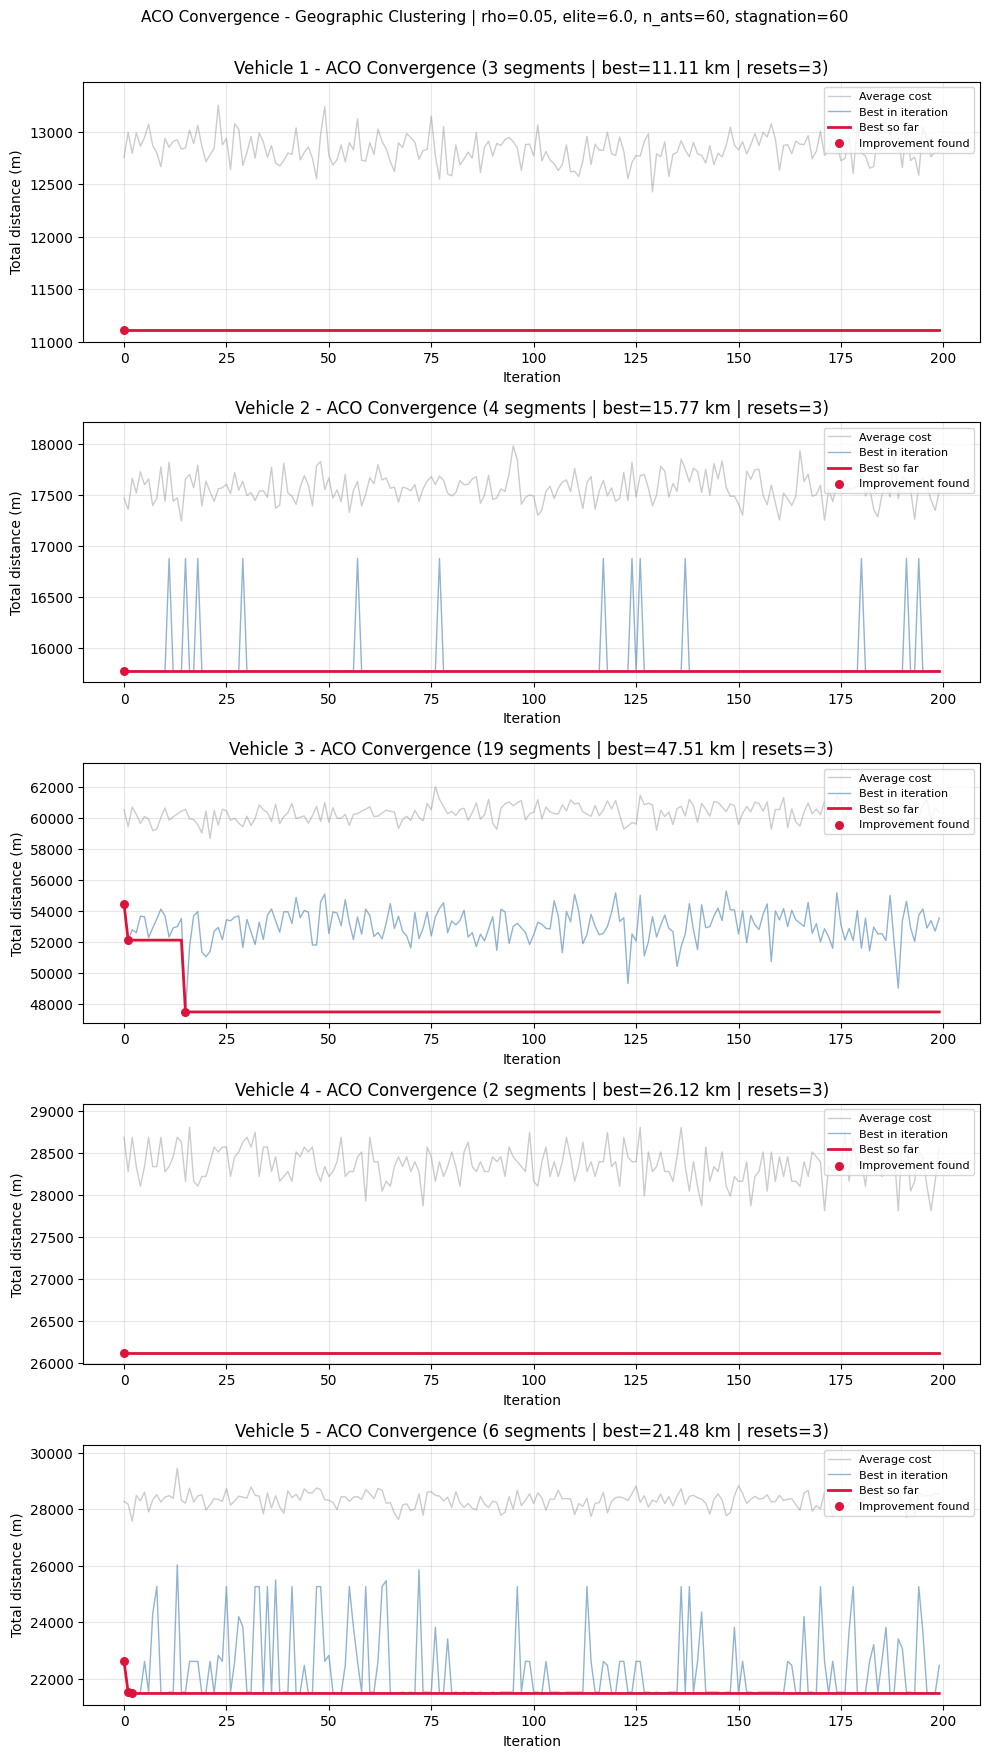

Plot disimpan ke aco_convergence_improved.png


In [ ]:
active_results = [r for r in vehicle_results if r['history']]
fig, axes = plt.subplots(
    nrows=max(1, len(active_results)), ncols=1,
    figsize=(10, 3.5 * max(1, len(active_results))), squeeze=False
)
for pi, r in enumerate(active_results):
    ax = axes[pi, 0]
    h = r['history']
    iters = range(len(h['best_so_far']))

    ax.plot(iters, h['avg_cost'],
            label='Average cost', alpha=0.4, color='gray', linewidth=1)
    ax.plot(iters, h['best_in_iteration'],
            label='Best in iteration', alpha=0.6, color='steelblue', linewidth=1)
    ax.plot(iters, h['best_so_far'],
            label='Best so far', color='crimson', linewidth=2)

    # Tandai titik perbaikan best-so-far dengan marker
    prev = float('inf')
    improve_iters, improve_vals = [], []
    for it, val in enumerate(h['best_so_far']):
        if val < prev - 1e-3:
            improve_iters.append(it)
            improve_vals.append(val)
            prev = val
    if improve_iters:
        ax.scatter(improve_iters, improve_vals,
                   color='crimson', s=30, zorder=5, label='Improvement found')

    reset_cnt = h.get('reset_count', 0)
    n_seg = len(r['seg_ids'])
    best_km = r['total_dist_m'] / 1000
    ax.set_title(
        f"Vehicle {r['vehicle_id']} - ACO Convergence "
        f"({n_seg} segments | best={best_km:.2f} km | resets={reset_cnt})"
    )
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Total distance (m)")
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

    # Sedikit ruang di atas agar title tidak menempel garis
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax + (ymax - ymin) * 0.05)

plt.suptitle(
    f"ACO Convergence - Geographic Clustering | "
    f"rho=0.05, elite=6.0, n_ants=60, stagnation=60",
    fontsize=11, y=1.002
)
plt.tight_layout()
plt.savefig('aco_convergence_improved.png', dpi=120, bbox_inches='tight')
plt.show()
print("Plot disimpan ke aco_convergence_improved.png")


## 9. Inspect Chosen Traversal Directions

In [ ]:
def segment_orientation_summary(order, orientations, segments):
    rows = []
    for step, (si, ori) in enumerate(zip(order, orientations), start=1):
        seg = segments[si]
        rows.append({"Step": step, "Segment": seg["name"],
            "Direction": "A->B" if ori==0 else "B->A",
            "Demand (L)": seg.get("demand", 0)})
    return pd.DataFrame(rows)

for r in vehicle_results:
    if not r['seg_ids']: continue
    print(f"\nVehicle {r['vehicle_id']} route:")
    display(segment_orientation_summary(r['best_order'], r['orientations'], SEGMENTS))



Vehicle 1 route:


,Step,Segment,Direction,Demand (L)
0,1,Jalan Nginden Semolo,B->A,1500.0
1,2,Jalan Raya Nginden,A->B,1920.0
2,3,Jalan Raya Menur,B->A,1800.0



Vehicle 2 route:


,Step,Segment,Direction,Demand (L)
0,1,Jalan Kertajaya,A->B,4455.0
1,2,Jalan Kertajaya,A->B,3543.8
2,3,Jalan Raya Kertajaya Indah,A->B,7500.0
3,4,Jalan Raya Menur,B->A,1743.8



Vehicle 3 route:


,Step,Segment,Direction,Demand (L)
0,1,Jalan Dharmahusada Indah Utara XIV,B->A,1518.8
1,2,Jalan Dharmahusada Permai,B->A,2205.0
2,3,Jalan Kalijudan,B->A,4908.8
3,4,Jalan Doktor Insinyur Haji Soekarno,A->B,2362.5
4,5,Jalan Dharmahusada Indah III,B->A,1068.8
5,6,Jalan Dharmahusada Indah I,A->B,1500.0
6,7,Jalan Dharmahusada Indah III,B->A,975.0
7,8,Jalan Dharmahusada Indah I,B->A,1500.0
8,9,Jalan Dharma Husada Indah II,B->A,1230.0
9,10,Jalan Raya Dharmahusada Indah,B->A,7560.0



Vehicle 4 route:


,Step,Segment,Direction,Demand (L)
0,1,Jalan Doktor Insinyur Haji Soekarno,B->A,7125.0
1,2,Jalan Doktor Insinyur Haji Soekarno,B->A,4095.0



Vehicle 5 route:


,Step,Segment,Direction,Demand (L)
0,1,Jalan Semolowaru,B->A,1050.0
1,2,Jalan Kedung Baruk,B->A,5932.5
2,3,Jalan Doktor Insinyur Haji Soekarno,B->A,3750.0
3,4,Jalan Arief Rahman Hakim,B->A,1428.8
4,5,Jalan Arief Rahman Hakim,A->B,6142.5
5,6,Jalan Doktor Insinyur Haji Soekarno,B->A,2610.0


## 10. Water Demand and Refill Simulation

Each vehicle starts at the depot with an empty tank, drives to its assigned water source to fill up (8000 L), then visits segments in order. Water is consumed per segment demand. When the tank is insufficient for the next segment, the vehicle detours to the nearest water source, refills, and continues.


In [ ]:
for r in vehicle_results:
    if not r['seg_ids']: continue
    plan, td, rc = simulate_route_with_refills(
        r['best_order'], r['orientations'], SEGMENTS, dist_matrix,
        WATER_SOURCE_INDICES, r['water_source_idx'], TANK_CAPACITY, RETURN_TO_DEPOT)
    r['refill_plan'] = plan; r['total_dist_with_refills_m'] = td; r['refill_count'] = rc
    seg_demand = sum(SEGMENTS[i]['demand'] for i in r['seg_ids'])
    print(f"\nVehicle {r['vehicle_id']:2d}: route_only={r['total_dist_m']:,.0f}m | "
          f"with_refills={td:,.0f}m | refills={rc} | demand={seg_demand:,.0f}L")
    for leg in plan:
        if leg['type'] == 'drive_to_water':
            print(f"   REFILL: {leg['label']} (+{leg['distance_m']:,.0f}m)")

print(f"\n{'='*80}")
print("FLEET SUMMARY WITH REFILLS")
print(f"{'='*80}")
tfdr = sum(r.get('total_dist_with_refills_m', 0) for r in vehicle_results)
tr = sum(r.get('refill_count', 0) for r in vehicle_results)
for r in vehicle_results:
    if r['seg_ids']:
        print(f"  Vehicle {r['vehicle_id']:2d}: {r.get('total_dist_with_refills_m',0):>10,.0f} m "
              f"({r.get('total_dist_with_refills_m',0)/1000:.2f} km)  refills={r.get('refill_count',0)}")
print(f"  Fleet total : {tfdr:>10,.0f} m ({tfdr/1000:.2f} km)  total refills={tr}")



Vehicle  1: route_only=11,106m | with_refills=11,106m | refills=1 | demand=5,220L
   REFILL: Depot -> Water Sungai Seberang Apartemen Gunawangsa Menur (initial fill) (+1,867m)

Vehicle  2: route_only=15,773m | with_refills=15,773m | refills=3 | demand=17,243L
   REFILL: Depot -> Water Sungai Depan SPBU Manyar (Dekat RS Bedah) (initial fill) (+2,014m)
   REFILL: Refill at Water Selokan Dharmahusada Indah (water=1L < demand=7500L) (+2,660m)
   REFILL: Refill at Water Sungai Seberang Apartemen Gunawangsa Menur (water=500L < demand=1744L) (+1,598m)

Vehicle  3: route_only=47,512m | with_refills=47,512m | refills=8 | demand=52,344L
   REFILL: Depot -> Water Selokan Dekat Resto Niki Sae (initial fill) (+3,194m)
   REFILL: Refill at Water Selokan Dekat Resto Niki Sae (water=4276L < demand=4909L) (+1,341m)
   REFILL: Refill at Water Selokan Dekat Resto Niki Sae (water=729L < demand=1069L) (+594m)
   REFILL: Refill at Water Selokan Dekat Resto Niki Sae (water=1726L < demand=7560L) (+1,134m)
  

## 11. Reconstruct Full Route Geometry with OSRM Route

In [ ]:
route_cache = {}

def route_key(p1, p2):
    return (round(p1[0],6), round(p1[1],6), round(p2[0],6), round(p2[1],6))

def osrm_route(p1, p2, overview="full", geometries="geojson"):
    key = route_key(p1, p2)
    if key in route_cache: return route_cache[key]
    coords = f"{p1[1]:.6f},{p1[0]:.6f};{p2[1]:.6f},{p2[0]:.6f}"
    url = (f"{OSRM_BASE}/route/v1/{PROFILE}/{coords}"
           f"?overview={overview}&geometries={geometries}&steps=false")
    r = requests.get(url, timeout=120); r.raise_for_status()
    data = r.json()
    if data.get("code") != "Ok": raise RuntimeError(data)
    route = data["routes"][0]; geom = route["geometry"]["coordinates"]
    latlon = [(lat, lon) for lon, lat in geom]
    out = {"distance_m": float(route["distance"]), "duration_s": float(route["duration"]),
           "geometry_latlon": latlon, "raw": data}
    route_cache[key] = out
    return out

print("osrm_route helper ready.")

for r in vehicle_results:
    if not r['seg_ids']:
        r['full_route_coords'] = []; r['leg_summaries'] = []; continue
    frc = []; ls = []
    for i, leg in enumerate(r.get('refill_plan', []), start=1):
        fp = SNAPPED_POINTS[leg['from_idx']]; tp = SNAPPED_POINTS[leg['to_idx']]
        res = osrm_route(fp, tp)
        geom = res['geometry_latlon']
        if frc and geom: geom = geom[1:]
        frc.extend(geom)
        ls.append({'leg_no':i, 'type':leg['type'], 'label':leg['label'],
                   'distance_m':res['distance_m'], 'duration_min':res['duration_s']/60.0})
    r['full_route_coords'] = frc; r['leg_summaries'] = ls
    rtm = sum(x['distance_m'] for x in ls)
    print(f"Vehicle {r['vehicle_id']:2d}: ACO={r['total_dist_m']:,.0f}m  "
          f"w/refills={r.get('total_dist_with_refills_m',0):,.0f}m  "
          f"OSRM_recon={rtm:,.0f}m  refills={r.get('refill_count',0)}")


osrm_route helper ready.
Vehicle  1: ACO=11,106m  w/refills=11,106m  OSRM_recon=11,106m  refills=1
Vehicle  2: ACO=15,773m  w/refills=15,773m  OSRM_recon=15,773m  refills=3
Vehicle  3: ACO=47,512m  w/refills=47,512m  OSRM_recon=47,512m  refills=8
Vehicle  4: ACO=26,120m  w/refills=26,120m  OSRM_recon=26,120m  refills=2
Vehicle  5: ACO=21,476m  w/refills=21,476m  OSRM_recon=21,476m  refills=4


## 12. Visualize on Interactive OSM Map

In [ ]:
output_dir = Path("Output")
output_dir.mkdir(exist_ok=True)

VEHICLE_COLORS = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd',
                  '#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf']

def add_arrows(fmap, coords, color, n_arrows=6, arrow_size=12):
    if len(coords) < 2: return
    cd = [0.0]
    for i in range(1, len(coords)):
        cd.append(cd[-1] + math.hypot(coords[i][0]-coords[i-1][0], coords[i][1]-coords[i-1][1]))
    total = cd[-1]
    if total == 0: return
    for frac in [(k+1)/(n_arrows+1) for k in range(n_arrows)]:
        target = frac * total; si = 1
        while si < len(cd)-1 and cd[si] < target: si += 1
        sl = cd[si] - cd[si-1]; t = (target - cd[si-1])/sl if sl > 0 else 0
        lat = coords[si-1][0] + t*(coords[si][0]-coords[si-1][0])
        lon = coords[si-1][1] + t*(coords[si][1]-coords[si-1][1])
        dy, dx = coords[si][0]-coords[si-1][0], coords[si][1]-coords[si-1][1]
        b = math.degrees(math.atan2(dx, dy)) % 360
        html = (f'<div style="width:0;height:0;border-left:{arrow_size//2}px solid transparent;'
                f'border-right:{arrow_size//2}px solid transparent;'
                f'border-bottom:{arrow_size}px solid {color};'
                f'transform:rotate({b:.1f}deg);transform-origin:50% 100%;'
                f'opacity:0.85;margin-top:-{arrow_size}px;"></div>')
        folium.Marker((lat,lon), icon=folium.DivIcon(html=html, icon_size=(arrow_size,arrow_size))).add_to(fmap)

def build_vehicle_map(r_list, title_label="All Vehicles"):
    m = folium.Map(location=DEPOT, zoom_start=13,
        tiles='https://tile.openstreetmap.de/{z}/{x}/{y}.png', attr='OSM contributors')

    # Marker Depot Utama
    folium.Marker(DEPOT, tooltip='DEPOT', icon=folium.Icon(color='red', icon='home', prefix='fa')).add_to(m)

    for i_vehicle, r in enumerate(r_list):
        if not r['seg_ids']: continue

        vc = VEHICLE_COLORS[(r['vehicle_id']-1) % len(VEHICLE_COLORS)]
        vl = f"Vehicle {r['vehicle_id']}"

        # --- FITUR FILTER LAYER ---
        # Atur agar hanya rute pertama (index 0) yang tampil otomatis saat peta dibuka.
        # Sisanya disembunyikan (show=False) agar peta tidak penuh/kusut.
        is_visible = True if i_vehicle == 0 else False
        vehicle_group = folium.FeatureGroup(name=vl, show=is_visible)

        # Ambil rencana perjalanan lengkap (refill_plan)
        plan = r.get('refill_plan', [])

        for i, leg in enumerate(plan, start=1):
            fp = SNAPPED_POINTS[leg['from_idx']]
            tp = SNAPPED_POINTS[leg['to_idx']]

            # Ambil rute asli jalan raya lewat OSRM
            res = osrm_route(fp, tp)

            # Tentukan gaya garis: Putus-putus jika sedang ambil air (Refill)
            line_dash = '10, 10' if leg['type'] == 'drive_to_water' else None

            # Gambar Garis Rute (dimasukkan ke vehicle_group, bukan m)
            folium.PolyLine(
                res['geometry_latlon'],
                color=vc,
                weight=4,
                opacity=0.8,
                dash_array=line_dash,
                tooltip=f"{vl} Langkah {i}: {leg['label']}"
            ).add_to(vehicle_group)

            # Penomoran di setiap titik henti
            icon_color = "blue" if leg['type'] == 'drive_to_water' else vc

            # Gambar Marker Angka (dimasukkan ke vehicle_group, bukan m)
            folium.Marker(
                tp,
                icon=folium.DivIcon(html=f'''
                    <div style="font-size:9pt; font-weight:bold; color:white;
                    background:{icon_color}; border:2px solid white; border-radius:5px;
                    padding:2px 5px; min-width:20px; text-align:center;
                    box-shadow:0 0 4px rgba(0,0,0,0.5);">
                        {i}
                    </div>'''),
                tooltip=f"{vl} Urutan ke-{i}: {leg['label']}"
            ).add_to(vehicle_group)

        # Tambahkan seluruh grup kendaraan ini ke peta
        vehicle_group.add_to(m)

    # Memunculkan kotak filter/Layer Control di pojok kanan atas
    folium.LayerControl(collapsed=False).add_to(m)

    return m

print("Generating combined map...")
m_all = build_vehicle_map(vehicle_results)
m_all.save(output_dir / "map_all_vehicles_aco.html")
print(f"  Saved: {output_dir / 'map_all_vehicles_aco.html'}")

active = [r for r in vehicle_results if r['seg_ids']]
print(f"Generating {len(active)} individual maps...")
for r in active:
    mv = build_vehicle_map([r])
    fn = output_dir / f"map_vehicle_{r['vehicle_id']}_aco.html"
    mv.save(fn); print(f"  Saved: {fn}")
print("\nDisplaying combined map:")
m_all


Generating combined map...
  Saved: Output/map_all_vehicles_aco.html
Generating 5 individual maps...
  Saved: Output/map_vehicle_1_aco.html
  Saved: Output/map_vehicle_2_aco.html
  Saved: Output/map_vehicle_3_aco.html
  Saved: Output/map_vehicle_4_aco.html
  Saved: Output/map_vehicle_5_aco.html

Displaying combined map:
